# Engression for counterfactual prediction on a broken causal dataset

- Generate broken data with DGP functions
    - verify & vis. weak overlap
 
- Estimations
    - baseline estimators with t-/s-learner framework
    - engression estimator
    - engression + AIPW estimator
    
- Experiment Results
    - single results
    - monte carlo results

# Packages & Utils

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import arrow
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from engression import engression

from src.dgp import generate_data, make_weak_overlap
#import for simulations
from src.models import *

In [55]:
sns.set_theme(style="whitegrid")
np.random.seed(123)
torch.manual_seed(123)

In [62]:
def to_csv_w_suffix(df, filename, suffix=None):
    if suffix is None:
        suffix = arrow.now().format("YYYY-MM-DD-hh-mm")
    output_file = f"{filename}-{suffix}.csv"
    df.to_csv(output_file, index=False)
    return

In [63]:
def get_xy(df, include_treat=False):
    X = df[feature_cols].to_numpy(dtype=float)
    T = df[treat_col].to_numpy(dtype=float)
    Y = df[outcome_col].to_numpy(dtype=float)
    if include_treat:
        X = np.column_stack([X, T])
    return X, T, Y

def clip_ps(ps, eps=0.01):
    return np.clip(ps, eps, 1 - eps)

def fit_propensity_logit(df):
    X, T, _ = get_xy(df, include_treat=False)
    ps_model = LogisticRegression(max_iter=3000)
    ps_model.fit(X, T)
    ps_hat = ps_model.predict_proba(X)[:, 1]
    return ps_model, clip_ps(ps_hat)

def ate_from_mu(mu0, mu1):
    return np.mean(mu1 - mu0)

def ipw_ate(y, t, ps):
    return np.mean(t * y / ps - (1 - t) * y / (1 - ps))

def aipw_ate(y, t, ps, mu0, mu1):
    score = (
        (mu1 - mu0)
        + t * (y - mu1) / ps
        - (1 - t) * (y - mu0) / (1 - ps)
    )
    return np.mean(score)

def summarize_against_truth(estimates, true_ate=None):
    out = pd.DataFrame({
        "method": list(estimates.keys()),
        "estimate": list(estimates.values())
    })
    if true_ate is not None:
        out["true_ate"] = true_ate
        out["error"] = out["estimate"] - true_ate
        out["abs_error"] = out["error"].abs()
    return out.sort_values("estimate").reset_index(drop=True)

# 1. Generate broken data

In [57]:
df, true_ate = generate_data(n_samples=2000, p=25, seed=538)
print("="*50)

Samples       : 2000
Covariates    : 25
Treated units : 1010  (50.5%)
Control units : 990  (49.5%)
True ATE      : 1.1028
E[e(X)]       : 0.5000
Y mean        : 1.5759
Y std         : 1.5868


In [ ]:
# broken data
bdf = make_weak_overlap(df, true_ate=true_ate, gamma=6.0, seed=538)

Samples       : 1059  (dropped 941 of 2000)
Gamma         : 6.0
Covariates    : 25
Treated units : 474  (44.8%)
Control units : 585  (55.2%)
True ATE      : 1.1028
E[e(X)]       : 0.4558
Y mean        : 1.5924
Y std         : 1.8120
e(X) < 0.1    : 35.5% of surviving units
e(X) > 0.9    : 25.1% of surviving units
0.1–0.9       : 39.4% of surviving units


In [59]:
bdf['true_ate'] = true_ate

## 1.2 Basic inspection

In [60]:
feature_cols = [c for c in bdf.columns if c.lower().startswith("x")]

treat_col = "T"
outcome_col = "Y"

true_cate_col = "true_cate" if "true_cate" in bdf.columns else None
true_ps_col = "propensity" if "propensity" in bdf.columns else None

print("feature_cols:", feature_cols)
print("true_cate_col:", true_cate_col)
print("true_ps_col:", true_ps_col)

feature_cols: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25']
true_cate_col: None
true_ps_col: None


## 1.3 Diagnose overlap / selection bias

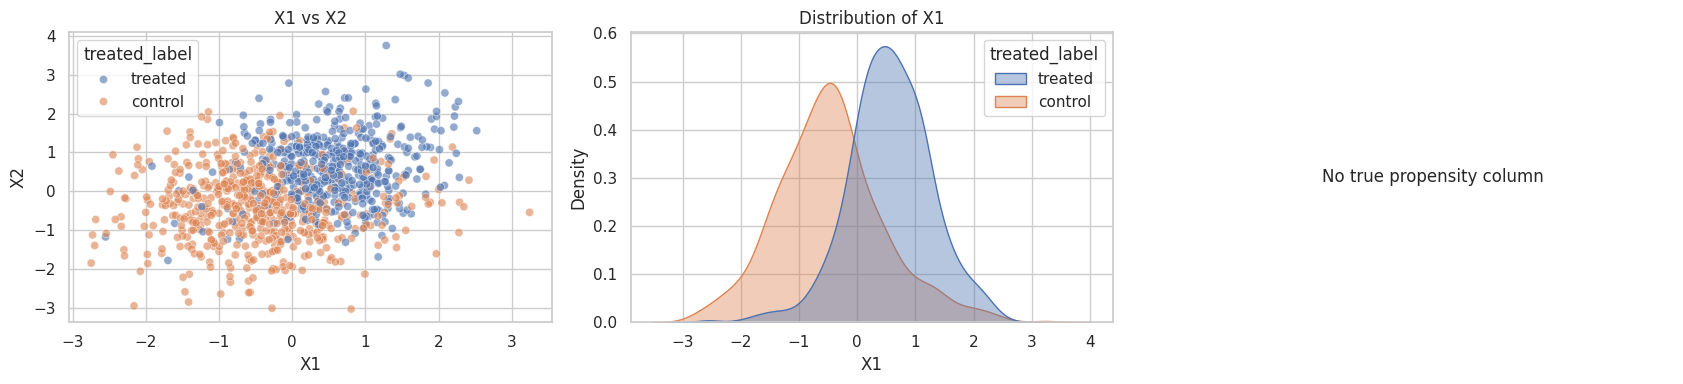

In [61]:
plot_df = bdf.copy()
plot_df["treated_label"] = np.where(plot_df[treat_col] == 1, "treated", "control")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

if len(feature_cols) >= 2:
    sns.scatterplot(
        data=plot_df, x=feature_cols[0], y=feature_cols[1],
        hue="treated_label", alpha=0.6, s=35, ax=axes[0]
    )
    axes[0].set_title(f"{feature_cols[0]} vs {feature_cols[1]}")
else:
    axes[0].text(0.5, 0.5, "Need at least 2 X columns", ha="center", va="center")
    axes[0].set_axis_off()

sns.kdeplot(
    data=plot_df, x=feature_cols[0], hue="treated_label",
    fill=True, common_norm=False, alpha=0.4, ax=axes[1]
)
axes[1].set_title(f"Distribution of {feature_cols[0]}")

if true_ps_col is not None:
    sns.kdeplot(
        data=plot_df, x=true_ps_col, hue="treated_label",
        fill=True, common_norm=False, alpha=0.4, ax=axes[2]
    )
    axes[2].set_title("True propensity distribution")
else:
    axes[2].text(0.5, 0.5, "No true propensity column", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.savefig("cov-dist.png")
plt.show()

## 2. Estimations

### S-learner
Single model for $P(Y \mid X, T)$

### T-learner
Two models for $P(Y \mid X, T=1), P(Y \mid X, T=0)$

## 3.1 Linear Regressions

In [64]:
def fit_ols_s_learner(df):
    X_st, T, Y = get_xy(df, include_treat=True)
    model = LinearRegression().fit(X_st, Y)

    X1 = X_st.copy()
    X0 = X_st.copy()
    X1[:, -1] = 1.0
    X0[:, -1] = 0.0

    mu1 = model.predict(X1)
    mu0 = model.predict(X0)
    return model, mu0, mu1


def fit_ridge_s_learner(df):
    X_st, T, Y = get_xy(df, include_treat=True)
    model = Ridge(alpha=1.0).fit(X_st, Y)

    X1 = X_st.copy()
    X0 = X_st.copy()
    X1[:, -1] = 1.0
    X0[:, -1] = 0.0

    mu1 = model.predict(X1)
    mu0 = model.predict(X0)
    return model, mu0, mu1

def fit_ols_t_learner(df):
    X, T, Y = get_xy(df, include_treat=False)
    model0 = LinearRegression().fit(X[T == 0], Y[T == 0])
    model1 = LinearRegression().fit(X[T == 1], Y[T == 1])

    mu0 = model0.predict(X)
    mu1 = model1.predict(X)
    return (model0, model1), mu0, mu1

## 3.2 Random Forest Regressor w/ AIPW

In [23]:
def fit_rf_s_learner(df):

    X_st, T, Y = get_xy(df, include_treat=True)
    model = RandomForestRegressor().fit(X_st, Y)

    X1 = X_st.copy()
    X0 = X_st.copy()
    X1[:, -1] = 1.0
    X0[:, -1] = 0.0

    mu1 = model.predict(X1)
    mu0 = model.predict(X0)

    return model, mu0, mu1


def fit_rf_t_learner(df):
    
    X, T, Y = get_xy(df, include_treat=False)

    treated_mask = (T == 1)
    control_mask = (T == 0)

    X1_train = X[treated_mask]
    Y1_train = Y[treated_mask]

    X0_train = X[control_mask]
    Y0_train = Y[control_mask]

    model1 = RandomForestRegressor().fit(X1_train, Y1_train)
    model0 = RandomForestRegressor().fit(X0_train, Y0_train)

    mu1 = model1.predict(X)
    mu0 = model0.predict(X)

    return (model0, model1), mu0, mu1

## 3.3 Engression outcome models

In [65]:
def to_torch(x):
    return torch.from_numpy(np.asarray(x)).to(torch.float32)

def fit_engression_s_learner(
    df,
    lr=0.01,
    num_epochs=600,
    batch_size=512,
    sample_size=200,
    device="cpu",
    verbose=True
):
    X_st, T, Y = get_xy(df, include_treat=True)
    X_torch = to_torch(X_st)
    Y_torch = to_torch(Y.reshape(-1, 1))

    model = engression(
        X_torch,
        Y_torch,
        lr=lr,
        num_epochs=num_epochs,
        batch_size=batch_size,
        device=device,
        verbose=verbose
    )

    X1 = X_torch.clone()
    X0 = X_torch.clone()
    X1[:, -1] = 1.0
    X0[:, -1] = 0.0

    mu1 = model.predict(X1, target="mean", sample_size=sample_size).reshape(-1).cpu().numpy()
    mu0 = model.predict(X0, target="mean", sample_size=sample_size).reshape(-1).cpu().numpy()
    return model, mu0, mu1

def fit_engression_t_learner(
    df,
    lr=0.01,
    num_epochs=600,
    batch_size=512,
    sample_size=200,
    device="cpu",
    verbose=True
):
    X, T, Y = get_xy(df, include_treat=False)
    X_torch = to_torch(X)
    Y_torch = to_torch(Y.reshape(-1, 1))
    T_bool = T.astype(bool)

    model0 = engression(
        X_torch[~T_bool],
        Y_torch[~T_bool],
        lr=lr,
        num_epochs=num_epochs,
        batch_size=batch_size,
        device=device,
        verbose=verbose
    )
    model1 = engression(
        X_torch[T_bool],
        Y_torch[T_bool],
        lr=lr,
        num_epochs=num_epochs,
        batch_size=batch_size,
        device=device,
        verbose=verbose
    )

    mu0 = model0.predict(X_torch, target="mean", sample_size=sample_size).reshape(-1).cpu().numpy()
    mu1 = model1.predict(X_torch, target="mean", sample_size=sample_size).reshape(-1).cpu().numpy()
    return (model0, model1), mu0, mu1

## 7. Run one-shot comparison on the broken dataset

In [66]:
def run_single_experiment(
    df,
    eng_num_epochs=500,
    eng_batch_size=512,
    eng_lr=0.01,
    eng_sample_size=200,
    ps_source="estimated",
    device="cpu",
    verbose=True
):
    X, T, Y = get_xy(df, include_treat=False)

    # Propensity score
    _, ps_hat = fit_propensity_logit(df)
    if ps_source == "true" and true_ps_col is not None:
        ps = clip_ps(df[true_ps_col].to_numpy())
    else:
        ps = ps_hat

    # OLS
    _, mu0_ols_s, mu1_ols_s = fit_ols_s_learner(df)
    _, mu0_ols_t, mu1_ols_t = fit_ols_t_learner(df)

    # Ridge
    _, mu0_ridge, mu1_ridge = fit_ridge_s_learner(df)


    # Random Forest
    _, mu0_rf_s, mu1_rf_s = fit_rf_s_learner(df)
    _, mu0_rf_t, mu1_rf_t = fit_rf_t_learner(df)

    # Engression
    _, mu0_eng_s, mu1_eng_s = fit_engression_s_learner(
        df,
        lr=eng_lr,
        num_epochs=eng_num_epochs,
        batch_size=eng_batch_size,
        sample_size=eng_sample_size,
        device=device,
        verbose=verbose
    )
    _, mu0_eng_t, mu1_eng_t = fit_engression_t_learner(
        df,
        lr=eng_lr,
        num_epochs=eng_num_epochs,
        batch_size=eng_batch_size,
        sample_size=eng_sample_size,
        device=device,
        verbose=verbose
    )

    estimates = {
        "OLS_S_direct": ate_from_mu(mu0_ols_s, mu1_ols_s),
        "OLS_T_direct": ate_from_mu(mu0_ols_t, mu1_ols_t),
        "IPW": ipw_ate(Y, T, ps),
        "AIPW_OLS_S": aipw_ate(Y, T, ps, mu0_ols_s, mu1_ols_s),
        "AIPW_OLS_T": aipw_ate(Y, T, ps, mu0_ols_t, mu1_ols_t),
        "AIPW_Ridge_S": aipw_ate(Y, T, ps, mu0_ridge, mu1_ridge),
        "AIPW_RF_S": aipw_ate(Y, T, ps, mu0_rf_s, mu1_rf_s),
        "AIPW_RF_T": aipw_ate(Y, T, ps, mu0_rf_t, mu1_rf_t),
        "Eng_S_direct": ate_from_mu(mu0_eng_s, mu1_eng_s),
        "Eng_T_direct": ate_from_mu(mu0_eng_t, mu1_eng_t),
        "AIPW_Eng_S": aipw_ate(Y, T, ps, mu0_eng_s, mu1_eng_s),
        "AIPW_Eng_T": aipw_ate(Y, T, ps, mu0_eng_t, mu1_eng_t),
    }

    true_ate = df[true_cate_col].mean() if true_cate_col is not None else None
    res = summarize_against_truth(estimates, true_ate=true_ate)
    res['true_ate'] = 1.1028
    res['bias'] = single_res.estimate - single_res.true_ate
    res['abs_error'] = abs(single_res.estimate - single_res.true_ate)
    return res

In [31]:
single_res = run_single_experiment(
    bdf,
    eng_num_epochs=500,
    eng_batch_size=min(512, len(bdf)),
    eng_lr=0.01,
    eng_sample_size=200,
    ps_source="estimated",
    device="cpu",
)

Running on CPU.

Data is standardized for training only; the printed training losses are on the standardized scale. 
However during evaluation, the predictions, evaluation metrics, and plots will be on the original scale.

Training based on mini-batch gradient descent with a batch size of 512.
[Epoch 1 (0%), batch 2] energy-loss: 0.6289,  E(|Y-Yhat|): 0.8511,  E(|Yhat-Yhat'|): 0.4445
[Epoch 100 (20%), batch 2] energy-loss: 0.3041,  E(|Y-Yhat|): 0.6571,  E(|Yhat-Yhat'|): 0.7061
[Epoch 200 (40%), batch 2] energy-loss: 0.2824,  E(|Y-Yhat|): 0.5995,  E(|Yhat-Yhat'|): 0.6342
[Epoch 300 (60%), batch 2] energy-loss: 0.2609,  E(|Y-Yhat|): 0.5670,  E(|Yhat-Yhat'|): 0.6122
[Epoch 400 (80%), batch 2] energy-loss: 0.2392,  E(|Y-Yhat|): 0.5317,  E(|Yhat-Yhat'|): 0.5850
[Epoch 500 (100%), batch 2] energy-loss: 0.2183,  E(|Y-Yhat|): 0.4680,  E(|Yhat-Yhat'|): 0.4994

Training loss on the original (non-standardized) scale:
	Energy-loss: 0.3958,  E(|Y-Yhat|): 0.8740,  E(|Yhat-Yhat'|): 0.9563

Prediction

In [30]:
single_res.sort_values(['abs_error'])

,method,estimate,true_ate,bias,abs_error
2,AIPW_Eng_T,1.114097,1.1028,0.011297,0.011297
1,Eng_T_direct,1.037116,1.1028,-0.065684,0.065684
0,IPW,1.022290,1.1028,-0.080510,0.080510
3,AIPW_RF_T,1.274081,1.1028,0.171281,0.171281
4,AIPW_RF_S,1.297073,1.1028,0.194273,0.194273
5,AIPW_OLS_S,1.298280,1.1028,0.195480,0.195480
6,AIPW_OLS_T,1.299201,1.1028,0.196401,0.196401
7,AIPW_Ridge_S,1.303281,1.1028,0.200481,0.200481
8,AIPW_Eng_S,1.496054,1.1028,0.393254,0.393254
9,Eng_S_direct,1.640766,1.1028,0.537966,0.537966


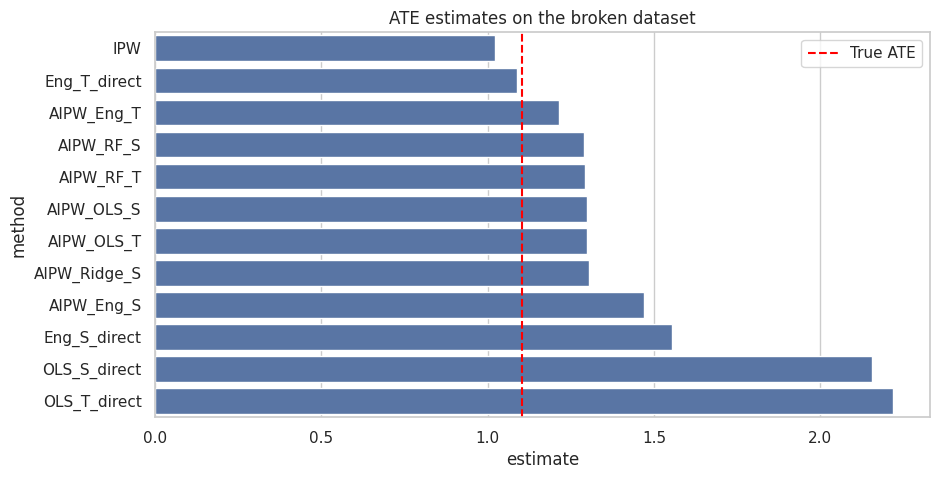

In [68]:
plot_res = single_res.copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_res, x="estimate", y="method")
if "true_ate" in plot_res.columns:
    plt.axvline(plot_res["true_ate"].iloc[0], color="red", linestyle="--", label="True ATE")
    plt.legend()
plt.title("ATE estimates on the broken dataset")
plt.show()

# 4. Monte-Carlo Simulation

In [43]:
from tqdm import tqdm

def run_mc(
    df,
    n_rep=10,
    eng_num_epochs=500,
    eng_batch_size=512,
    eng_lr=0.01,
    eng_sample_size=1000,
    device="cpu",
    verbose=True
):
    rows = []
    for rep in tqdm(range(n_rep)):
        # df = simulator_fn(seed=1000 + rep)
        one = run_single_experiment(
            df,
            eng_num_epochs=eng_num_epochs,
            eng_batch_size=min(eng_batch_size, len(df)),
            eng_lr=eng_lr,
            eng_sample_size=eng_sample_size,
            device=device,
            verbose=verbose
        ).copy()
        one["rep"] = rep
        rows.append(one)
    return pd.concat(rows, ignore_index=True)

# Example usage:
mc_res = run_mc(bdf, verbose=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [05:58<00:00, 35.87s/it]


In [45]:
mc_res

,method,estimate,true_ate,bias,abs_error,rep
0,IPW,1.022290,1.1028,-0.080510,0.080510,0
1,AIPW_Eng_T,1.185204,1.1028,-0.015075,0.015075,0
2,Eng_T_direct,1.194827,1.1028,0.110942,0.110942,0
3,AIPW_RF_T,1.279493,1.1028,0.185965,0.185965,0
4,AIPW_RF_S,1.290915,1.1028,0.188691,0.188691,0
...,...,...,...,...,...,...
115,AIPW_RF_S,1.305255,1.1028,0.200481,0.200481,9
116,AIPW_Eng_S,1.477716,1.1028,0.367698,0.367698,9
117,Eng_S_direct,1.511196,1.1028,0.452817,0.452817,9
118,OLS_S_direct,2.155579,1.1028,1.052779,1.052779,9


In [69]:
mc_res.method.value_counts()

method
IPW             10
AIPW_Eng_T      10
Eng_T_direct    10
AIPW_RF_T       10
AIPW_RF_S       10
AIPW_OLS_S      10
AIPW_OLS_T      10
AIPW_Ridge_S    10
Eng_S_direct    10
AIPW_Eng_S      10
OLS_S_direct    10
OLS_T_direct    10
Name: count, dtype: int64

In [71]:
mc_res.groupby(['method']).agg(
    n=('abs_error', 'count'),
    mae=('abs_error', 'mean'),
    rmse=('abs_error', lambda x: np.sqrt(np.mean(np.square(x))))
).reset_index().sort_values('rmse')

,method,n,mae,rmse
8,Eng_T_direct,10,0.034248,0.051414
9,IPW,10,0.080510,0.080510
1,AIPW_Eng_T,10,0.115727,0.130902
5,AIPW_RF_T,10,0.173230,0.176055
4,AIPW_RF_S,10,0.182184,0.183804
2,AIPW_OLS_S,10,0.192765,0.192793
3,AIPW_OLS_T,10,0.196033,0.196033
6,AIPW_Ridge_S,10,0.198849,0.198859
0,AIPW_Eng_S,10,0.384722,0.386226
7,Eng_S_direct,10,0.435794,0.437122


In [76]:
# mc_res.to_csv("mc-outcome-results-3.csv", index=False)

## 3.2 100 MC Simulation

In [48]:
mc_res_1k = run_mc(bdf, n_rep=100, verbose=False)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [47:45<00:00, 28.65s/it]


In [49]:
mc_res_1k.groupby(['method']).agg(
    n=('abs_error', 'count'),
    mae=('abs_error', 'mean'),
    rmse=('abs_error', lambda x: np.sqrt(np.mean(np.square(x))))
).reset_index().sort_values('rmse')

,method,n,mae,rmse
8,Eng_T_direct,100,0.040683,0.058999
9,IPW,100,0.075929,0.077743
1,AIPW_Eng_T,100,0.096166,0.106631
5,AIPW_RF_T,100,0.185490,0.186347
4,AIPW_RF_S,100,0.187984,0.188547
2,AIPW_OLS_S,100,0.192384,0.192416
3,AIPW_OLS_T,100,0.195752,0.195758
6,AIPW_Ridge_S,100,0.199157,0.199167
0,AIPW_Eng_S,100,0.381317,0.382592
7,Eng_S_direct,100,0.439198,0.440305


In [53]:
to_csv_w_suffix(mc_res_1k, "../mc-res-100")

# 5. Conclusions

- T-learner outperforms S-learner in weaker overlap cases
    - Our other simulations show that when overlap is stronger or when p is higher (e.g. p = 50), S-learner will better

- Engression plug-in ATE estimation has lowest MAE, and RMSE, outperforming other baseline methods.

- Engression-induced method improves the AIPW + OLS baseline by around 60% (0.19 to 0.07, MAE)

- IPW estimator kind of has better results than AIPW, which is a little weird